In [170]:
# %pip install matplotlib

In [171]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import time
start_time= time.time()


In [172]:
dataset = pd.read_csv('https://raw.githubusercontent.com/TomasMantero/Predicting-House-Prices-Keras-ANN/master/kc_house_data.csv')


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'sqft_living'}>,
        <Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'waterfront'}>],
       [<Axes: title={'center': 'view'}>,
        <Axes: title={'center': 'condition'}>,
        <Axes: title={'center': 'grade'}>,
        <Axes: title={'center': 'sqft_above'}>],
       [<Axes: title={'center': 'sqft_basement'}>,
        <Axes: title={'center': 'yr_built'}>,
        <Axes: title={'center': 'yr_renovated'}>,
        <Axes: title={'center': 'zipcode'}>],
       [<Axes: title={'center': 'lat'}>,
        <Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>,
        <Axes: title={'center': 'sqft_lot15'}>]], dtype=object)

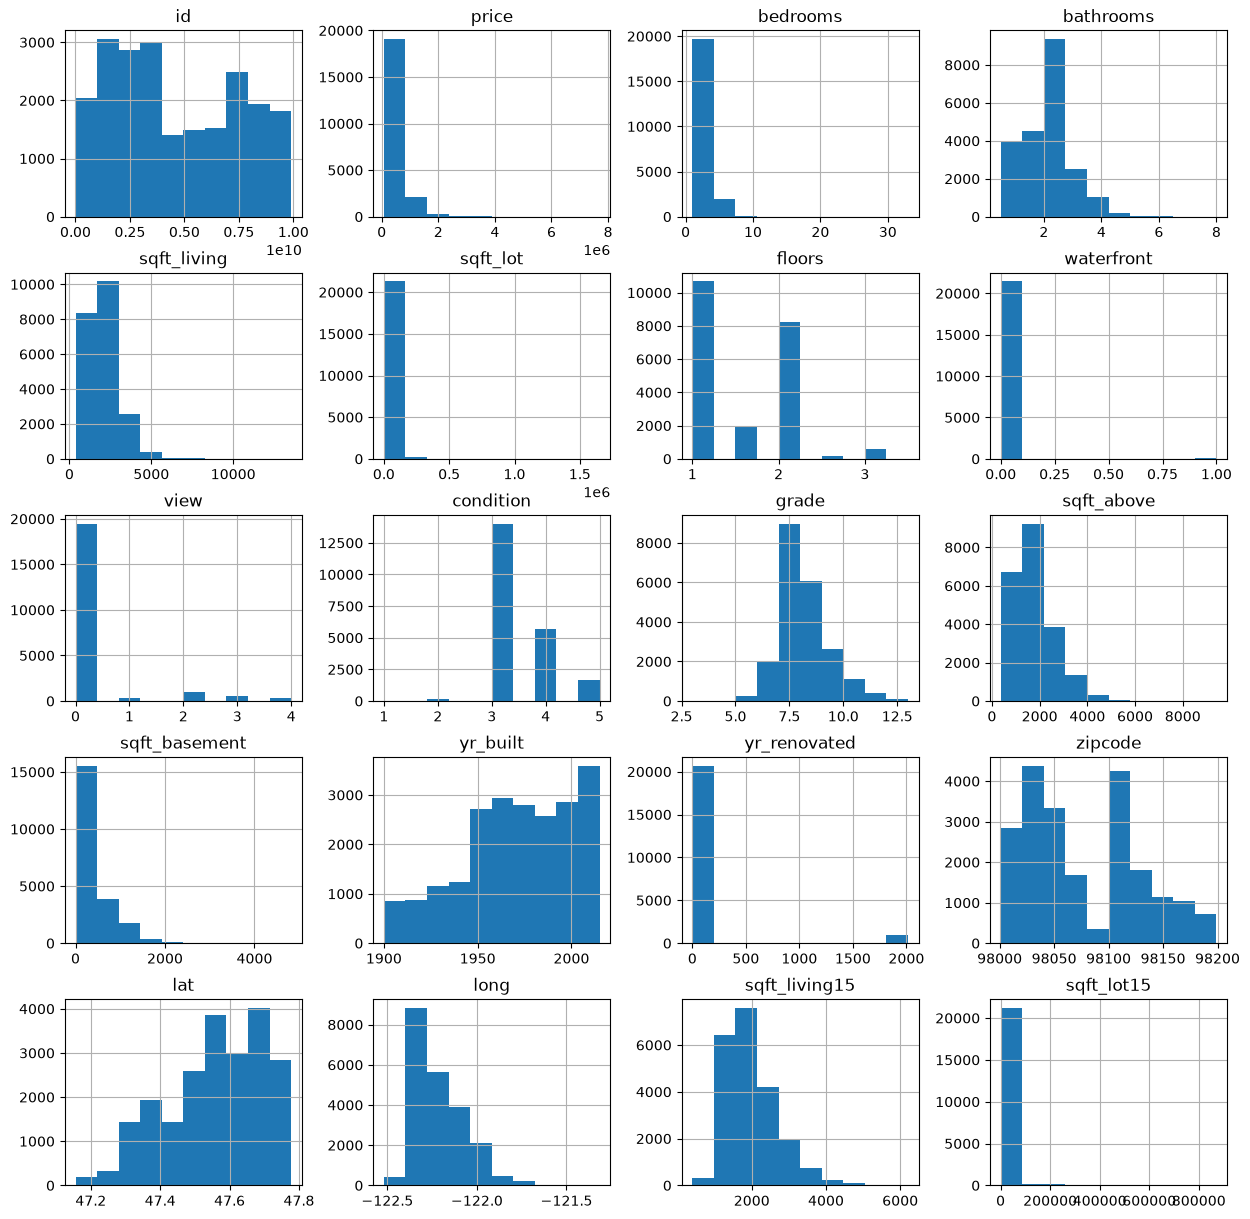

In [173]:
dataset.hist(figsize=(15,15))

In [174]:
dataset=dataset.drop(['date','sqft_lot','waterfront','view','yr_renovated','sqft_lot15'],axis=1)

In [175]:
def normalizar(x, xmax, xmin, ymax, ymin):
    m=(ymax-ymin)/(xmax-xmin)
    b=ymin - m*xmin

    y = m*x+b
    return y

In [176]:
max= dataset.max().values
min=dataset.min().values
data=normalizar(dataset,max,min,1,0)
data.head(5)

,id,price,bedrooms,bathrooms,sqft_living,floors,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15
0,0.720103,0.018880,0.06250,0.066667,0.061503,0.0,0.5,0.4,0.089602,0.000000,0.478261,0.893939,0.571498,0.217608,0.161934
1,0.647853,0.060352,0.06250,0.233333,0.167046,0.4,0.5,0.4,0.199115,0.082988,0.443478,0.626263,0.908959,0.166113,0.222165
2,0.568795,0.013382,0.03125,0.066667,0.030372,0.0,0.5,0.3,0.044248,0.000000,0.286957,0.136364,0.936143,0.237542,0.399415
3,0.251157,0.069011,0.09375,0.333333,0.120729,0.0,1.0,0.4,0.075221,0.188797,0.565217,0.681818,0.586939,0.104651,0.165376
4,0.197333,0.056678,0.06250,0.200000,0.099468,0.0,0.5,0.5,0.144912,0.000000,0.756522,0.368687,0.741354,0.393688,0.241094


In [177]:
X = data.drop('price',axis=1)
Y=data['price']
X.head(5)

,id,bedrooms,bathrooms,sqft_living,floors,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15
0,0.720103,0.06250,0.066667,0.061503,0.0,0.5,0.4,0.089602,0.000000,0.478261,0.893939,0.571498,0.217608,0.161934
1,0.647853,0.06250,0.233333,0.167046,0.4,0.5,0.4,0.199115,0.082988,0.443478,0.626263,0.908959,0.166113,0.222165
2,0.568795,0.03125,0.066667,0.030372,0.0,0.5,0.3,0.044248,0.000000,0.286957,0.136364,0.936143,0.237542,0.399415
3,0.251157,0.09375,0.333333,0.120729,0.0,1.0,0.4,0.075221,0.188797,0.565217,0.681818,0.586939,0.104651,0.165376
4,0.197333,0.06250,0.200000,0.099468,0.0,0.5,0.5,0.144912,0.000000,0.756522,0.368687,0.741354,0.393688,0.241094


In [178]:
Y.head(5)

0    0.018880
1    0.060352
2    0.013382
3    0.069011
4    0.056678
Name: price, dtype: float64

### Reproducibility with `torch.manual_seed(42)`

When training neural networks, PyTorch initializes weights and shuffles datasets randomly. To ensure that your results are **reproducible** (meaning you get the exact same results every time you run the code), you set a **random seed**.

#### Quick Python Example:
```python
import torch

# 1. Without setting a seed, you get different random numbers each time
print(torch.rand(2))  # e.g., tensor([0.1234, 0.5678])
print(torch.rand(2))  # e.g., tensor([0.9876, 0.4321])

# 2. With a set seed, the random numbers are locked and reproducible
torch.manual_seed(42)
print(torch.rand(2))  # Will output: tensor([0.8823, 0.9150])

torch.manual_seed(42)
print(torch.rand(2))  # Will output EXACTLY: tensor([0.8823, 0.9150]) again!


In [179]:
torch.manual_seed(42)

In [180]:
X_train,X_test,Y_train,Y_test = train_test_split(X.values, Y.values, test_size=0.3)
X_train, Y_train = torch.tensor(X_train,dtype=torch.float32), torch.tensor(Y_train, dtype=torch.float32)

input_shape=(X_train.shape[1])
print(input_shape)

14


In [181]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1= nn.Linear(input_dim,16)
        self.layer2=nn.Linear(16,1)

    def forward(self,x):
        x=nn.functional.relu(self.layer1(x))
        x=self.layer2(x)
        return x
model= Model(X_train.shape[1])
print(model)

Model(
  (layer1): Linear(in_features=14, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=1, bias=True)
)


In [182]:
criterion =nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [183]:
num_epochs =50
batch_size = 100
train_losses = []
test_losses= []

In [184]:
for epoch in range(num_epochs):
    for i in range(0, X_train.shape[0], batch_size):
        inputs= torch.tensor(X_train[i:i+batch_size], dtype=torch.float32)
        targets = torch.tensor(Y_train[i:i+batch_size], dtype=torch.float32)

        optimizer.zero_grad()
        outputs= model(inputs)

        loss=criterion(outputs, targets)
        loss.backward()

        optimizer.step()

    train_loss = criterion(model(torch.tensor(X_train, dtype=torch.float32)),torch.tensor(Y_train,dtype=torch.float32))
    train_losses.append(train_loss)

    test_loss = criterion(model(torch.tensor(X_test, dtype=torch.float32)), torch.tensor(Y_test, dtype=torch.float32))
    test_losses.append(test_loss)

    print(f"Epoch {epoch+1}, train loss: {train_loss}, test loss: {test_loss}")



/var/folders/l3/74l7x8h972ngrkjgzm3hc7200000gn/T/ipykernel_34106/2115083306.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs= torch.tensor(X_train[i:i+batch_size], dtype=torch.float32)
/var/folders/l3/74l7x8h972ngrkjgzm3hc7200000gn/T/ipykernel_34106/2115083306.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(Y_train[i:i+batch_size], dtype=torch.float32)
/opt/homebrew/lib/python3.11/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([100])) that is different to the input size (torch.Size([100, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_

Epoch 1, train loss: 0.0023429456632584333, test loss: 0.0024937402922660112
Epoch 2, train loss: 0.0023072471376508474, test loss: 0.0024580287281423807
Epoch 3, train loss: 0.0022963075898587704, test loss: 0.002446678699925542
Epoch 4, train loss: 0.0022907941602170467, test loss: 0.002440930576995015
Epoch 5, train loss: 0.0022875892464071512, test loss: 0.0024375994689762592
Epoch 6, train loss: 0.0022854753769934177, test loss: 0.002435441827401519
Epoch 7, train loss: 0.0022839787416160107, test loss: 0.0024339354131370783
Epoch 8, train loss: 0.0022828620858490467, test loss: 0.002432811539620161
Epoch 9, train loss: 0.0022819996811449528, test loss: 0.0024319461081176996
Epoch 10, train loss: 0.0022813512478023767, test loss: 0.0024313044268637896
Epoch 11, train loss: 0.002280835062265396, test loss: 0.002430798253044486
Epoch 12, train loss: 0.0022804252803325653, test loss: 0.0024303982499986887
Epoch 13, train loss: 0.0022801076993346214, test loss: 0.0024300795048475266
E

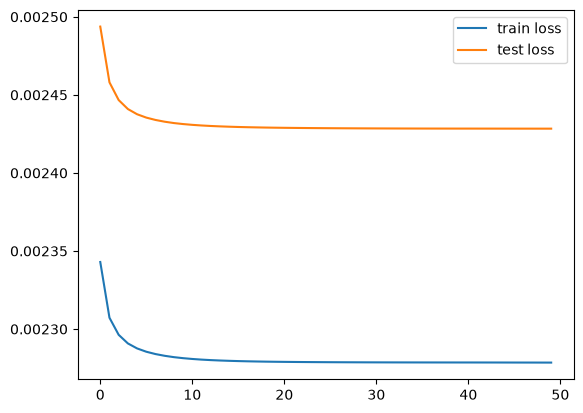

In [185]:
import matplotlib.pyplot as plt

# Extract plain Python numbers (floats) from the list of tensors
train_losses_list = [loss.item() for loss in train_losses]
test_losses_list = [loss.item() for loss in test_losses]

# Plot the plain Python lists (no NumPy or tensors involved!)
plt.plot(train_losses_list, label='train loss')
plt.plot(test_losses_list, label='test loss')
plt.legend()
plt.show()



In [186]:
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
print(tensor_X_test[:4])


tensor([[0.9047, 0.0938, 0.2667, 0.2087, 0.4000, 0.5000, 0.6000, 0.3040, 0.0000,
         0.9913, 0.0000, 0.2207, 0.2118, 0.3913],
        [0.6181, 0.0625, 0.2000, 0.1062, 0.0000, 0.7500, 0.4000, 0.1548, 0.0000,
         0.4783, 0.8333, 0.4586, 0.1470, 0.2531],
        [0.1384, 0.0625, 0.3667, 0.2468, 0.4000, 0.5000, 0.7000, 0.2611, 0.1846,
         0.9130, 1.0000, 0.7775, 0.0963, 0.2600],
        [0.2314, 0.0625, 0.2333, 0.0750, 0.8000, 0.5000, 0.4000, 0.1093, 0.0000,
         0.9304, 0.6667, 0.8835, 0.1437, 0.1650]])


In [187]:
tensor_y_test = torch.tensor(Y_test, dtype=torch.float32)
print(tensor_y_test[:4])
     

tensor([0.0609, 0.0547, 0.1236, 0.0306])


In [188]:
# Evaluar el modelo en el conjunto de prueba
y_pred = model(torch.tensor(X_test, dtype=torch.float32)).detach().tolist()
print(y_pred[:4])

[[0.059944890439510345], [0.06028563156723976], [0.061503201723098755], [0.05956481397151947]]


In [189]:
# Convertir los valores de y_test y y_pred a tensores de PyTorch
y_test_tensor = torch.tensor(Y_test)
y_pred_tensor = torch.tensor(y_pred)

# Calcular el MSE
mse = torch.nn.functional.mse_loss(y_pred_tensor, y_test_tensor)
mae = torch.nn.functional.l1_loss(y_pred_tensor, y_test_tensor)

# Calcular el RMSE
rmse = torch.sqrt(mse)

print('RMSE:', rmse)
print('MAE:', mae.item())

/var/folders/l3/74l7x8h972ngrkjgzm3hc7200000gn/T/ipykernel_34106/1086525995.py:6: UserWarning: Using a target size (torch.Size([6480])) that is different to the input size (torch.Size([6480, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mse = torch.nn.functional.mse_loss(y_pred_tensor, y_test_tensor)
/var/folders/l3/74l7x8h972ngrkjgzm3hc7200000gn/T/ipykernel_34106/1086525995.py:7: UserWarning: Using a target size (torch.Size([6480])) that is different to the input size (torch.Size([6480, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mae = torch.nn.functional.l1_loss(y_pred_tensor, y_test_tensor)


RMSE: tensor(0.0493, dtype=torch.float64)
MAE: 0.030940642799976492


In [190]:

print("Total time taken:", time.time() - start_time, "seconds.")


Total time taken: 20.02631115913391 seconds.


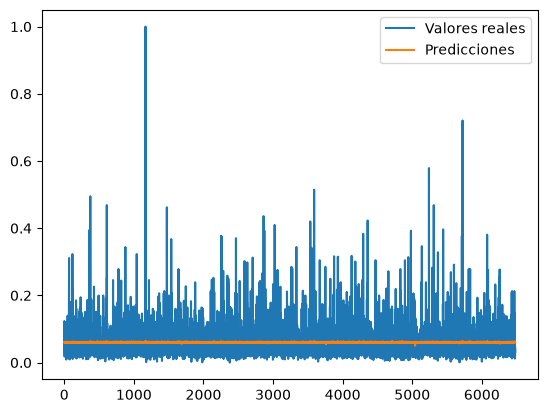

In [191]:
# Obtener las predicciones
y_pred = model(torch.tensor(X_test, dtype=torch.float32)).detach().tolist()

# Graficar las predicciones en comparación con los valores reales
plt.plot(Y_test, label='Valores reales')
plt.plot(y_pred, label='Predicciones')
plt.legend()
plt.show()

In [192]:
print("Total time taken:", time.time() - start_time, "seconds.")


Total time taken: 20.095506191253662 seconds.
